In [1]:
import glob 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from scipy.stats import gmean
import re

In [2]:
# Read in the cd8_t expression results
cd8_t = pd.read_csv('../data/all_cd8_t_cells_patient_updated_patient_updated.csv', index_col=0)


In [3]:
# Read in clustering results
df_clust = pd.read_excel('../data/2024_06_25_Annotations.xlsx')
df_clust_dict = dict(zip(df_clust['FlowSOM_Cluster'], df_clust['Annotation']))
df_clust_dict

to_keep = [x for x, y in df_clust_dict.items() if y == 'CD56pos_GzmBpos']
        
        

In [4]:
# Select the cytotoxic cells
print(cd8_t.shape)
cd8_t = cd8_t.loc[cd8_t['FlowSOM_metacluster'].isin(to_keep), :]
print(cd8_t.shape)

(2343096, 67)
(549552, 67)


In [5]:
# Delete spare progression sample (there was a second later measurement which was associated with progression)
# Delete sample 61290 006 as the patient went off trial due to participant preference

cd8_t = cd8_t.loc[cd8_t['FileName'] != 'P02_SPD_T_Cell_Panel',:]
cd8_t = cd8_t.loc[~cd8_t['FileName'].str.contains('P26'),:]
cd8_t['FileName'] = cd8_t['FileName'].str.replace('P02_SPD_2_T_Cell_Panel', 'P02_SPD_T_Cell_Panel')

# Delete the following samples as they have only a single measurement
cd8_t = cd8_t.loc[~cd8_t['FileName'].str.contains('P27'),:]
cd8_t = cd8_t.loc[~cd8_t['FileName'].str.contains('P15'),:]
cd8_t.head()

,Unnamed: 0,209Bi_CD45,Center,164Dy,166Er_CD34,Event_length,157Gd,113In_CD45,191Ir_DNA1,193Ir_DNA2,...,152Sm_CD159c_asinh_coarseAlign_fineAlign,169Tm_CD25_asinh_coarseAlign_fineAlign,171Yb_Granzyme_B_asinh_coarseAlign_fineAlign,172Yb_CD38_asinh_coarseAlign_fineAlign,173Yb_CD14_asinh_coarseAlign_fineAlign,174Yb_HLA-DR_asinh_coarseAlign_fineAlign,176Yb_CD56_asinh_coarseAlign_fineAlign,Alignment_MC_fineAlign,FlowSOM_cluster,FlowSOM_metacluster
10,11,0.000000,813.257,0.0,1.37723,16,0.0,0.0,187.980,380.536,...,0.001935,0.004979,3.628160,2.459838,0.095055,0.335255,4.836486,5,43,12
12,13,3.868140,1040.140,0.0,0.00000,22,0.0,0.0,107.537,188.784,...,0.006105,0.011151,5.900617,1.252931,0.014530,0.073580,3.116467,7,37,3
19,20,4.099470,1007.430,0.0,0.00000,24,0.0,0.0,150.425,282.338,...,0.297066,0.011151,6.152333,1.048356,0.014530,0.314892,2.825187,7,37,3
42,43,0.417838,878.096,0.0,4.00957,19,0.0,0.0,192.489,423.187,...,0.006105,0.011151,4.892740,1.991302,0.014530,0.073580,2.370739,7,24,2
56,57,0.156017,544.768,0.0,0.00000,16,0.0,0.0,215.124,332.167,...,0.006105,0.011151,3.990620,0.067627,0.014530,0.296675,2.023160,7,44,12


In [6]:
# Rename columns to permit easier plotting
cd8_t.columns = [col.split('_')[1] if '_' in col else col for col in cd8_t.columns]
cd8_t.columns = cd8_t.columns.str.replace('Granzyme', 'Granzyme_B')
cd8_t.columns = cd8_t.columns.str.replace('CD335', 'NKp46')
cd8_t.columns = cd8_t.columns.str.replace('CD279', 'PD1')


In [7]:
# Calculate the geometric mean of each molecule
filename = []
molecule = []
expression = []
timepoint =[]
for i in cd8_t['FileName'].unique():
    for j in cd8_t.loc[:, 'NKp46':'CD56']:
        a = cd8_t.loc[cd8_t['FileName'] == i, j]
        b = [i+0.01 for i in a]
        c = gmean(b)
        filename.append(i)
        molecule.append(j)
        expression.append(c)

/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_stats_py.py:247: RuntimeWarning: invalid value encountered in log
  log_a = xp.log(a)


In [8]:
# Create a new dataframe which contains the geometric mean of each molecule
cd8_nkt = pd.DataFrame()            
cd8_nkt['FileName'] = filename
cd8_nkt['Molecule'] = molecule
cd8_nkt['Expression'] = expression
cd8_nkt

,FileName,Molecule,Expression
0,P08_C1_D8_T_Cell_Panel,NKp46,0.031092
1,P08_C1_D8_T_Cell_Panel,FoxP3,0.490303
2,P08_C1_D8_T_Cell_Panel,CD183,0.097029
3,P08_C1_D8_T_Cell_Panel,CD33,0.344014
4,P08_C1_D8_T_Cell_Panel,Ki67,0.197370
...,...,...,...
3498,Control_11_T_Cell_Panel,Granzyme_B,6.642247
3499,Control_11_T_Cell_Panel,CD38,1.490245
3500,Control_11_T_Cell_Panel,CD14,0.101938
3501,Control_11_T_Cell_Panel,HLA-DR,0.525932


In [9]:
# Reshape the dataframe
cd8_nkt = cd8_nkt.groupby([cd8_nkt['FileName'], cd8_nkt['Molecule']]).mean()
cd8_nkt = cd8_nkt.reset_index()
cd8_nkt = cd8_nkt.pivot(index='FileName', columns='Molecule', values='Expression')
cd8_nkt = cd8_nkt.reset_index()
cd8_nkt

Molecule,FileName,CD11c,CD127,CD14,CD159c,CD16,CD183,CD19,CD194,CD197,...,CD8a,FoxP3,Granzyme_B,HLA-DR,KLRG1,Ki67,NKp46,PD1,Perforin,Tim3
0,Control_10_T_Cell_Panel,0.091045,0.116417,0.073333,0.043506,0.239478,0.107793,0.055559,0.325545,0.130811,...,2.270430,0.335072,5.565693,0.246591,2.288208,0.314961,0.025047,0.106162,6.940689,0.079562
1,Control_11_T_Cell_Panel,0.023169,0.040171,0.101938,0.028747,1.008554,0.095078,0.111038,0.222567,0.118825,...,2.920875,0.541271,6.642247,0.525932,3.661889,0.425615,0.032571,0.189288,3.542221,0.053788
2,Control_12_T_Cell_Panel,0.024509,0.041363,0.074393,0.023604,0.675210,0.074524,0.066368,0.248003,0.109081,...,2.820860,0.485422,6.123810,0.405169,3.150593,0.228084,0.019978,0.097721,3.938843,0.035670
3,Control_13_T_Cell_Panel,0.017576,0.137439,0.059024,0.016432,0.529572,0.102258,0.067191,0.298916,0.116982,...,2.385434,0.363653,4.572304,0.233729,2.949463,0.241622,0.034524,0.125040,2.660745,0.039480
4,Control_14_T_Cell_Panel,0.022901,0.102501,0.072967,0.019251,0.606537,0.098559,0.078167,0.335307,0.128947,...,2.678900,0.407598,5.436166,0.306187,2.441388,0.181376,0.033887,0.221709,2.913175,0.041116
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108,P25_C1_D8_T_Cell_Panel,0.014847,0.120547,0.057911,0.019666,0.596479,0.061633,0.102882,0.259901,0.104389,...,2.602220,0.405977,6.106506,0.347768,2.867420,0.161979,0.029062,0.193898,3.172609,0.027329
109,P28_C1_D1_T_Cell_Panel,0.184713,0.065624,0.119511,0.060413,0.279011,0.046714,0.066399,0.179223,0.061524,...,2.087034,0.406127,6.334765,0.511428,2.649472,0.338578,0.026870,0.073319,6.362687,0.170573
110,P28_C1_D8_T_Cell_Panel,0.024567,0.055071,0.077372,0.019478,0.834025,0.071049,0.089974,0.249605,0.114260,...,2.252173,0.287940,6.586918,0.374910,2.540219,0.168112,0.031475,0.071640,4.457355,0.052438
111,P38_C1_D1_T_Cell_Panel,0.073621,0.066520,0.123723,0.035567,0.325172,0.120544,0.048280,0.223973,0.088239,...,2.275555,0.568632,6.468315,0.322682,1.894520,0.187612,0.033395,0.079936,7.764029,0.038700


In [10]:
cd8_nkt.head(10)

Molecule,FileName,CD11c,CD127,CD14,CD159c,CD16,CD183,CD19,CD194,CD197,...,CD8a,FoxP3,Granzyme_B,HLA-DR,KLRG1,Ki67,NKp46,PD1,Perforin,Tim3
0,Control_10_T_Cell_Panel,0.091045,0.116417,0.073333,0.043506,0.239478,0.107793,0.055559,0.325545,0.130811,...,2.270430,0.335072,5.565693,0.246591,2.288208,0.314961,0.025047,0.106162,6.940689,0.079562
1,Control_11_T_Cell_Panel,0.023169,0.040171,0.101938,0.028747,1.008554,0.095078,0.111038,0.222567,0.118825,...,2.920875,0.541271,6.642247,0.525932,3.661889,0.425615,0.032571,0.189288,3.542221,0.053788
2,Control_12_T_Cell_Panel,0.024509,0.041363,0.074393,0.023604,0.675210,0.074524,0.066368,0.248003,0.109081,...,2.820860,0.485422,6.123810,0.405169,3.150593,0.228084,0.019978,0.097721,3.938843,0.035670
3,Control_13_T_Cell_Panel,0.017576,0.137439,0.059024,0.016432,0.529572,0.102258,0.067191,0.298916,0.116982,...,2.385434,0.363653,4.572304,0.233729,2.949463,0.241622,0.034524,0.125040,2.660745,0.039480
4,Control_14_T_Cell_Panel,0.022901,0.102501,0.072967,0.019251,0.606537,0.098559,0.078167,0.335307,0.128947,...,2.678900,0.407598,5.436166,0.306187,2.441388,0.181376,0.033887,0.221709,2.913175,0.041116
5,Control_15_T_Cell_Panel,0.018927,0.029864,0.073350,0.012754,0.493440,0.072707,0.076811,0.287425,0.117485,...,2.626601,0.329502,6.456861,0.718301,2.666975,0.174617,0.021252,0.054109,2.174149,0.026468
6,Control_16_T_Cell_Panel,0.797193,0.057303,0.056896,0.038536,0.849997,0.093944,0.060159,0.328033,0.110338,...,2.751036,0.331697,5.370402,0.241030,2.543298,0.179207,0.043164,0.084396,3.629397,0.048258
7,Control_17_T_Cell_Panel,0.027894,0.064677,0.075474,0.052792,0.892704,0.099923,0.067070,0.372349,0.121254,...,2.928275,0.364296,6.605128,0.607392,2.618310,0.222049,0.033182,0.147937,3.329868,0.040874
8,Control_18_T_Cell_Panel,0.791857,0.335182,0.043311,0.022235,0.492753,0.075755,0.056769,0.237889,0.094949,...,2.724511,0.353121,4.967510,0.199437,3.488217,0.144030,0.022987,0.162080,3.012116,0.020870
9,Control_19_T_Cell_Panel,0.013155,0.060969,0.046639,0.016864,0.474201,0.186628,0.067130,0.271055,0.091087,...,2.232469,0.396264,5.103329,0.289963,2.335497,0.156583,0.022804,0.060710,3.438339,0.026521


In [11]:
cd8_nkt.tail(10)

Molecule,FileName,CD11c,CD127,CD14,CD159c,CD16,CD183,CD19,CD194,CD197,...,CD8a,FoxP3,Granzyme_B,HLA-DR,KLRG1,Ki67,NKp46,PD1,Perforin,Tim3
103,P22_C7_D22_T_Cell_Panel,0.017930,0.037112,0.055150,0.017819,0.593677,0.078896,0.090581,0.302529,0.121345,...,2.528520,0.342459,5.819551,0.238005,3.101476,0.213273,0.029761,0.083182,2.914105,0.020748
104,P24_C1_D1_T_Cell_Panel,0.046026,0.067784,0.075471,0.174855,0.388028,0.095214,0.071091,0.233378,0.100820,...,2.298723,0.469506,5.985794,0.171381,3.519680,0.160391,0.022960,0.042500,7.377833,0.049360
105,P24_C1_D8_T_Cell_Panel,0.022894,0.115263,0.073494,0.032217,0.702297,0.104019,0.072769,0.322596,0.128627,...,2.514052,0.451800,5.676181,0.256718,3.211721,0.221981,0.029240,0.075646,3.470692,0.036403
106,P24_C7_D1_T_Cell_Panel,0.036827,0.112643,0.066554,0.035904,0.605002,0.095271,0.070343,0.295140,0.115743,...,2.669796,0.426161,5.406824,0.298798,3.311429,0.202741,0.029968,0.099372,3.157782,0.038086
107,P25_C1_D1_T_Cell_Panel,0.014559,0.102890,0.053605,0.018862,0.600359,0.070551,0.091471,0.289424,0.112506,...,2.564494,0.368327,5.758476,0.353391,2.840965,0.161515,0.027233,0.176022,2.788151,0.025482
108,P25_C1_D8_T_Cell_Panel,0.014847,0.120547,0.057911,0.019666,0.596479,0.061633,0.102882,0.259901,0.104389,...,2.602220,0.405977,6.106506,0.347768,2.867420,0.161979,0.029062,0.193898,3.172609,0.027329
109,P28_C1_D1_T_Cell_Panel,0.184713,0.065624,0.119511,0.060413,0.279011,0.046714,0.066399,0.179223,0.061524,...,2.087034,0.406127,6.334765,0.511428,2.649472,0.338578,0.026870,0.073319,6.362687,0.170573
110,P28_C1_D8_T_Cell_Panel,0.024567,0.055071,0.077372,0.019478,0.834025,0.071049,0.089974,0.249605,0.114260,...,2.252173,0.287940,6.586918,0.374910,2.540219,0.168112,0.031475,0.071640,4.457355,0.052438
111,P38_C1_D1_T_Cell_Panel,0.073621,0.066520,0.123723,0.035567,0.325172,0.120544,0.048280,0.223973,0.088239,...,2.275555,0.568632,6.468315,0.322682,1.894520,0.187612,0.033395,0.079936,7.764029,0.038700
112,P38_C1_D8_T_Cell_Panel,0.036307,0.081786,0.080421,0.027166,1.383709,0.132889,0.093771,0.515707,0.178243,...,2.303299,0.371328,NaN,0.293076,2.582416,0.292118,0.056376,0.179667,3.787563,0.066414


In [12]:
timepoint_dict = {}
patient_dict = {}
for x in cd8_nkt['FileName']:
    if x.startswith('P'):
        patient_dict[x] = x.split('_')[0]
    elif x.startswith('Control'):
        patient_dict[x] = x.split('_')[0] + '_' + x.split('_')[1]

for x in cd8_nkt['FileName']:
    if x.startswith('Control'):
        timepoint_dict[x] = 'Control'
    elif 'C1_D1' in x:
        timepoint_dict[x] = 'C1D1'
    elif 'C1_D8' in x:
        timepoint_dict[x] = 'C1D8'
    elif 'C7_D1' in x:
        timepoint_dict[x] = 'C7D1'
    elif 'C7_D22' in x:
        timepoint_dict[x] = 'C7D22'
    elif 'C12_D29' in x:
        timepoint_dict[x] = 'C12D29'
    elif 'SPD' in x:
        timepoint_dict[x] = 'SPD'

cd8_nkt['timepoint'] = cd8_nkt['FileName'].map(timepoint_dict)
cd8_nkt['patient_id'] = cd8_nkt['FileName'].map(patient_dict)

In [13]:
# Read in patient info sheet (this was sent to me by Julie on 2024_01_17)
patient_info = pd.read_excel('../data/Outcomes_master_simplified_updatedJan24_patient_updated.xlsx')
patient_info = patient_info.loc[~patient_info['Outcome_C6_revised_Vid'].isna(), :]
patient_info['PID'] = patient_info['PID'].astype(str)

# Create dictionaries so that I can add information to the dataframe such as 
# diagnosis and clinical outcomes

diagnosis_dx = dict(zip(patient_info['PID'], patient_info['Diagnosis']))

outcome_C6_dx = dict(zip(patient_info['PID'], patient_info['Outcome_C6_revised_Vid']))

outcome_C12_dx = dict(zip(patient_info['PID'], patient_info['Outcome_C12_CC486']))

In [14]:
# Use the dictionaries to add clinical outcomes to the dataframe
cd8_nkt['diagnosis'] = cd8_nkt['patient_id'].map(diagnosis_dx)
cd8_nkt['outcome_6'] = cd8_nkt['patient_id'].map(outcome_C6_dx)
cd8_nkt['outcome_12'] = cd8_nkt['patient_id'].map(outcome_C12_dx)
cd8_nkt

pid_timepoint = [f"{x}_{y}" if 'P' in x else x 
                 for x, y in zip(cd8_nkt['patient_id'], cd8_nkt['timepoint'])]

cd8_nkt['pid_timepoint'] = pid_timepoint
cd8_nkt['pid_timepoint'] = cd8_nkt['pid_timepoint'].astype(str)

In [15]:
# Read in data from Julie. This dataframe contains the patient outcomes and time when a sample was collected 
timepoints = pd.read_excel('../data/MS_flow_outcome_dx_clean_updatedJan24_patient_updated.xlsx')
timepoints['PID_Timepoint'] = timepoints['PID'].astype(str) + '_' + timepoints['Cycle_day']
to_keep = ['Cycle_day', 'Day_since_C1D1', 'Day_since_scr', 'PID_Timepoint']
timepoints = timepoints.loc[:,timepoints.columns.isin(to_keep)]
timepoints.head()
cd8_nkt_cytotoxic2 = pd.merge(cd8_nkt, timepoints, left_on='pid_timepoint', right_on= 'PID_Timepoint', how = 'left')


# # Update the clinical outcomes and diagnosis columns to reflect that there are healthy samples in the sample set
diagnosis = ['Healthy' if 'Healthy' in x else y 
            for x, y in zip(cd8_nkt_cytotoxic2['patient_id'], cd8_nkt_cytotoxic2['diagnosis'])]
        

outcome_6 = ['Healthy' if 'Healthy' in x else y 
            for x, y in zip(cd8_nkt_cytotoxic2['patient_id'], cd8_nkt_cytotoxic2['outcome_6'])]

outcome_12 = ['Healthy' if 'Healthy' in x else y 
            for x, y in zip(cd8_nkt_cytotoxic2['patient_id'], cd8_nkt_cytotoxic2['outcome_12'])]    

        
cd8_nkt_cytotoxic2['diagnosis'] = diagnosis
cd8_nkt_cytotoxic2['outcome_6'] = outcome_6
cd8_nkt_cytotoxic2['outcome_12'] = outcome_12

In [16]:
# Use a dictionary to add a column called time which will be used for plotting
time = {'C1_D1': 1, 'C1_D8': 8, 'C7_D1': 168, 'C7_D22': 190, 'C12_D29': 336,
    'SPD': 275,  'Control': 0.4}
    
cd8_nkt_cytotoxic2['time'] = cd8_nkt_cytotoxic2['timepoint'].map(time)
cd8_nkt_cytotoxic2.head()

,FileName,CD11c,CD127,CD14,CD159c,CD16,CD183,CD19,CD194,CD197,...,patient_id,diagnosis,outcome_6,outcome_12,pid_timepoint,Cycle_day,Day_since_C1D1,Day_since_scr,PID_Timepoint,time
0,Control_10_T_Cell_Panel,0.091045,0.116417,0.073333,0.043506,0.239478,0.107793,0.055559,0.325545,0.130811,...,Control_10,NaN,NaN,NaN,Control_10,NaN,NaN,NaN,NaN,0.4
1,Control_11_T_Cell_Panel,0.023169,0.040171,0.101938,0.028747,1.008554,0.095078,0.111038,0.222567,0.118825,...,Control_11,NaN,NaN,NaN,Control_11,NaN,NaN,NaN,NaN,0.4
2,Control_12_T_Cell_Panel,0.024509,0.041363,0.074393,0.023604,0.675210,0.074524,0.066368,0.248003,0.109081,...,Control_12,NaN,NaN,NaN,Control_12,NaN,NaN,NaN,NaN,0.4
3,Control_13_T_Cell_Panel,0.017576,0.137439,0.059024,0.016432,0.529572,0.102258,0.067191,0.298916,0.116982,...,Control_13,NaN,NaN,NaN,Control_13,NaN,NaN,NaN,NaN,0.4
4,Control_14_T_Cell_Panel,0.022901,0.102501,0.072967,0.019251,0.606537,0.098559,0.078167,0.335307,0.128947,...,Control_14,NaN,NaN,NaN,Control_14,NaN,NaN,NaN,NaN,0.4


In [17]:
# Create a list so that I can delete the samples where I acquired a C7D22 but the patient dropped out for
# reasons unrelated to the disease or treatment note that these patients have an NA in the outcome_12 column

time_to_keep = ['non-responder_2', 'responder_1', 'Healthy']
to_del = [x for x, y in zip(cd8_nkt_cytotoxic2['pid_timepoint'], cd8_nkt_cytotoxic2['outcome_12']) 
          if 'C7D22' in x and y not in time_to_keep]



print(cd8_nkt_cytotoxic2.shape)
cd8_nkt_cytotoxic2 = cd8_nkt_cytotoxic2.loc[~cd8_nkt_cytotoxic2['pid_timepoint'].isin(to_del), :]
print(cd8_nkt_cytotoxic2.shape)

(113, 43)
(111, 43)


In [18]:
# Add a column called best response which details the best clinical response of each patient
# if a patient is called a responder at any timepont they are called a responder even if they eventually progress
best_response = []
for x, y in zip(cd8_nkt_cytotoxic2['outcome_6'], cd8_nkt_cytotoxic2['outcome_12']):
    if (x == 'responder_1') | (y == 'responder_1'):
        best_response.append('responder_1')
    elif y == 'Healthy':
        best_response.append('Healthy')
    else:
        best_response.append('non-responder_2')

cd8_nkt_cytotoxic2['best_response'] = best_response

In [19]:
timepoint_dict = {'C1D1' : 2, 'C1D8' : 3, 'C7D1': 4, 'C7D22' : 5, 'C12D29' : 6, 'Progression' : 7, 'Healthy': 1}
cd8_nkt_cytotoxic2['time'] = cd8_nkt_cytotoxic2['timepoint'].map(timepoint_dict)
cd8_nkt_cytotoxic2

,FileName,CD11c,CD127,CD14,CD159c,CD16,CD183,CD19,CD194,CD197,...,diagnosis,outcome_6,outcome_12,pid_timepoint,Cycle_day,Day_since_C1D1,Day_since_scr,PID_Timepoint,time,best_response
0,Control_10_T_Cell_Panel,0.091045,0.116417,0.073333,0.043506,0.239478,0.107793,0.055559,0.325545,0.130811,...,NaN,NaN,NaN,Control_10,NaN,NaN,NaN,NaN,NaN,non-responder_2
1,Control_11_T_Cell_Panel,0.023169,0.040171,0.101938,0.028747,1.008554,0.095078,0.111038,0.222567,0.118825,...,NaN,NaN,NaN,Control_11,NaN,NaN,NaN,NaN,NaN,non-responder_2
2,Control_12_T_Cell_Panel,0.024509,0.041363,0.074393,0.023604,0.675210,0.074524,0.066368,0.248003,0.109081,...,NaN,NaN,NaN,Control_12,NaN,NaN,NaN,NaN,NaN,non-responder_2
3,Control_13_T_Cell_Panel,0.017576,0.137439,0.059024,0.016432,0.529572,0.102258,0.067191,0.298916,0.116982,...,NaN,NaN,NaN,Control_13,NaN,NaN,NaN,NaN,NaN,non-responder_2
4,Control_14_T_Cell_Panel,0.022901,0.102501,0.072967,0.019251,0.606537,0.098559,0.078167,0.335307,0.128947,...,NaN,NaN,NaN,Control_14,NaN,NaN,NaN,NaN,NaN,non-responder_2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108,P25_C1_D8_T_Cell_Panel,0.014847,0.120547,0.057911,0.019666,0.596479,0.061633,0.102882,0.259901,0.104389,...,AML,non-responder_2,NaN,P25_C1D8,C1D8,9.0,41.0,P25_C1D8,3.0,non-responder_2
109,P28_C1_D1_T_Cell_Panel,0.184713,0.065624,0.119511,0.060413,0.279011,0.046714,0.066399,0.179223,0.061524,...,MDS,non-responder_2,NaN,P28_C1D1,C1D1,0.0,16.0,P28_C1D1,2.0,non-responder_2
110,P28_C1_D8_T_Cell_Panel,0.024567,0.055071,0.077372,0.019478,0.834025,0.071049,0.089974,0.249605,0.114260,...,MDS,non-responder_2,NaN,P28_C1D8,C1D8,12.0,28.0,P28_C1D8,3.0,non-responder_2
111,P38_C1_D1_T_Cell_Panel,0.073621,0.066520,0.123723,0.035567,0.325172,0.120544,0.048280,0.223973,0.088239,...,MDS,non-responder_2,NaN,P38_C1D1,C1D1,0.0,19.0,P38_C1D1,2.0,non-responder_2


In [20]:
# # Read in p-values
# pval = pd.read_excel('../data/2024_11_12_pvalues_from_jake.xlsx', sheet_name= 'Slide_5')
# pval['Cell_type'] = pval['Cell_type'].str.replace('HLA_DR', 'HLA-DR')
# pval['Cell_type'] = pval['Cell_type'].str.replace('GZMB', 'Granzyme_B')


/var/folders/8n/0q8k5j814xj4bcjqhcvny6p80000gn/T/ipykernel_92549/3724819847.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cd8_nkt_cytotoxic2['time1'] = timejitter
/var/folders/8n/0q8k5j814xj4bcjqhcvny6p80000gn/T/ipykernel_92549/3724819847.py:39: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(data = cd8_nkt_cytotoxic3, x = 'time', y = cd8_nkt_cytotoxic3.loc[:, figure_list[y]], err_style = 'bars',
/var/folders/8n/0q8k5j814xj4bcjqhcvny6p80000gn/T/ipykernel_92549/3724819847.py:39: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(data = cd8_nkt_cytotoxic3, x = 'time', y = cd8_nkt_cytotoxic3.loc[:, figure_list[y]], err_style = 

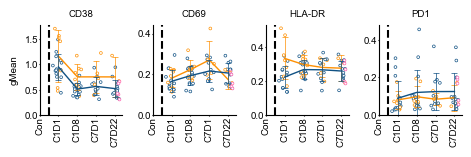

In [21]:
# Make a multiplot of all the graphs for 

# Set font
plt.rcParams["font.family"] = "Arial"
plt.rcParams['svg.fonttype'] = 'none' # export font as editable text
plt.rcParams['pdf.fonttype'] = 'truetype' # export font as editable text

color_dict = {'non-responder_2': '#fe9003', 'responder_1': '#115284', 'Healthy': 'grey'}

cd8_nkt_cytotoxic2 = cd8_nkt_cytotoxic2.loc[cd8_nkt_cytotoxic2['timepoint'] != 'C12D29']


fig, axs = plt.subplots(nrows = 1, ncols = 4, figsize = (6.69 * 0.72, 6.69 * 0.25))
axs_flatten = axs.flatten()

stars = cd8_nkt_cytotoxic2.loc[cd8_nkt_cytotoxic2['timepoint'] == 'SPD', :]['patient_id'].str.replace('_', '').to_list()
figure_list = ['CD38', 'CD69', 'HLA-DR', 'PD1']

jitter_amount = 0.75  # Adjust the jitter amount as needed

x_jitter = np.random.normal(1, jitter_amount, size = cd8_nkt.shape[0])
timejitter =  []
for z, (w, x, y) in enumerate(zip(cd8_nkt_cytotoxic2['time'], cd8_nkt_cytotoxic2['patient_id'], x_jitter)): 
    if (w == 5) & (x in stars): 
        timejitter.append(w + (y/10))
    elif z % 2 == 0:
        timejitter.append(w + (y/10))
    else:
        timejitter.append(w - (y/10))
cd8_nkt_cytotoxic2['time1'] = timejitter

stars1 = cd8_nkt_cytotoxic2.loc[(cd8_nkt_cytotoxic2['patient_id'].isin(stars)) &  (cd8_nkt_cytotoxic2['timepoint'] == 'C7D22'), :]
cd8_nkt_cytotoxic3 = cd8_nkt_cytotoxic2.loc[cd8_nkt['timepoint'] != 'Progression',:]

for y, ax in enumerate(axs_flatten):

        ax.scatter(x = cd8_nkt_cytotoxic3.loc[:,'time1'], y = cd8_nkt_cytotoxic3.loc[:, figure_list[y]], 
              c = 'white', edgecolor = cd8_nkt_cytotoxic3.loc[:,'best_response'].map(color_dict), s =4, lw = 0.5)
        sns.lineplot(data = cd8_nkt_cytotoxic3, x = 'time', y = cd8_nkt_cytotoxic3.loc[:, figure_list[y]], err_style = 'bars',
                 ci = 'sd',  err_kws={'linewidth': 0.5, 'capsize':2, 'capthick': 0.5}, legend = False, hue = 'best_response',
                 palette = color_dict, linewidth = 1, ax = ax)
        ax.scatter(x = stars1['time1'], y = stars1[figure_list[y]], color = 'white', s =4, lw = 0.5, edgecolor = 'hotpink')
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)
        ax.set_ylim(bottom = 0)
        e = str(figure_list[y])
        # e = e.replace('_x', '')
        # e = e.replace('GzmB_pos_CD56_CD8_T_cell', 'GzmB+_CD56+_CD8_T_cell')
        # e = e.replace('GzmB_pos_CD8', 'GzmB+_CD8_T_cell')
        
        e = e.replace('_', ' ')
        
        ax.set_title(e, fontsize = 7)
        ax.axvline(1.5, color = 'black', ls = '--')
        ax.set_xticks([1, 2, 3, 4, 5])
        ax.set_xticklabels(['Con', 'C1D1', 'C1D8', 'C7D1', 'C7D22'], rotation = 90, fontsize = 7)
        ax.set_xlabel(xlabel = '',  fontsize = 7)
        ax.set_ylim(bottom = 0)
        ax.tick_params(axis='both', labelsize=7, pad = 0.1, length = 1)
        if (y % 4 == 0):
            ax.set_ylabel('gMean', fontsize  =7)
        else:
            ax.set_ylabel('', fontsize  =7 )
            
        # Get the axis limits
        xmin, xmax = ax.get_xlim()
        ymin, ymax = ax.get_ylim()
        
        # Calculate position as a percentage of the axis range
        x_pos = xmin + 0.3 * (xmax - xmin)  # 50% from left
        y_pos = ymax - 0.1 * (ymax - ymin)  # 5% from top

        # text = pval.loc[pval['Cell_type'] == figure_list[y], 'p_value'].iloc[0] 
        # text = round(pval.loc[pval['Cell_type'] == figure_list[y], 'p_value'].iloc[0], 3)
        # text = f'$\it{{p}} = {text}$'
        # ax.text(s = text, x = x_pos, y =  y_pos, fontsize = 7)
    
plt.tight_layout()
#fig.savefig('../results/cd56_pos_acitivation_moleculesfor_main_figure.pdf', dpi = 600)

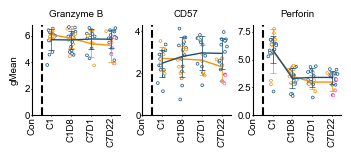

In [22]:

# Make a multiplot of all the graphs for cytotoxic molecules

# Set font
plt.rcParams["font.family"] = "Arial"
plt.rcParams['svg.fonttype'] = 'none' # export font as editable text
plt.rcParams['pdf.fonttype'] = 'truetype' # export font as editable text

color_dict = {'non-responder_2': '#fe9003', 'responder_1': '#115284', 'Healthy': 'grey'}

fig, axs = plt.subplots(nrows = 1, ncols = 3, figsize = (6.69 * 0.54, 6.69 * 0.25))
axs_flatten = axs.flatten()

cd8_nkt_cytotoxic2 = cd8_nkt_cytotoxic2.loc[cd8_nkt_cytotoxic2['timepoint'] != 'C12D29']
stars = cd8_nkt_cytotoxic2.loc[cd8_nkt_cytotoxic2['timepoint'] == 'SPD', :]['patient_id'].str.replace('_', '').to_list()
figure_list = ['Granzyme_B', 'CD57', 'Perforin']

jitter_amount = 0.75  # Adjust the jitter amount as needed

x_jitter = np.random.normal(1, jitter_amount, size = cd8_nkt.shape[0])
timejitter =  []
for z, (w, x, y) in enumerate(zip(cd8_nkt_cytotoxic2['time'], cd8_nkt_cytotoxic2['patient_id'], x_jitter)): 
    if (w == 5) & (x in stars): 
        timejitter.append(w + (y/10))
    elif z % 2 == 0:
        timejitter.append(w + (y/10))
    else:
        timejitter.append(w - (y/10))
cd8_nkt_cytotoxic2['time1'] = timejitter

stars1 = cd8_nkt_cytotoxic2.loc[(cd8_nkt_cytotoxic2['patient_id'].isin(stars)) &  (cd8_nkt_cytotoxic2['timepoint'] == 'C7D22'), :]
cd8_nkt_cytotoxic3 = cd8_nkt_cytotoxic2.loc[cd8_nkt['timepoint'] != 'Progression',:]

for y, ax in enumerate(axs_flatten):

        ax.scatter(x = cd8_nkt_cytotoxic3.loc[:,'time1'], y = cd8_nkt_cytotoxic3.loc[:, figure_list[y]], 
              c = 'white', edgecolor = cd8_nkt_cytotoxic3.loc[:,'best_response'].map(color_dict), s =4, lw = 0.5)
        sns.lineplot(data = cd8_nkt_cytotoxic3, x = 'time', y = cd8_nkt_cytotoxic3.loc[:, figure_list[y]], err_style = 'bars',
                 errorbar = 'sd',  err_kws={'linewidth': 0.5, 'capsize':2, 'capthick': 0.5}, legend = False, hue = 'best_response',
                 palette = color_dict, linewidth = 1, ax = ax)
        ax.scatter(x = stars1['time1'], y = stars1[figure_list[y]], color = 'white', s =4, edgecolor = 'hotpink', lw = 0.5)
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)
        ax.set_ylim(bottom = 0)
        e = str(figure_list[y])
        
        e = e.replace('_', ' ')
        
        ax.set_title(e, fontsize = 7)
        ax.axvline(1.5, color = 'black', ls = '--')
        ax.set_xticks([1, 2, 3, 4, 5, ])
        ax.set_xticklabels(['Con', 'C1', 'C1D8', 'C7D1', 'C7D22'], rotation = 90, fontsize = 7)
        ax.set_xlabel(xlabel = '',  fontsize = 7)
        ax.set_ylim(bottom = 0)
        ax.tick_params(axis='both', labelsize=7, pad = 0.1, length = 1)
        if (y % 4 == 0):
            ax.set_ylabel('gMean', fontsize  =7)
        else:
            ax.set_ylabel('', fontsize  =7 )
        
        # Get the axis limits
        xmin, xmax = ax.get_xlim()
        ymin, ymax = ax.get_ylim()
        
        # Calculate position as a percentage of the axis range
        x_pos = xmin + 0.3 * (xmax - xmin)  # 50% from left
        y_pos = ymax - 0.001 * (ymax - ymin)  # 5% from top

    
        
plt.tight_layout()
#fig.savefig('../results/cd56_pos_cytotoxic_moleculesfor_main_figure.pdf', dpi = 600)

In [23]:
cd8_nkt_cytotoxic2.columns

Index(['FileName', 'CD11c', 'CD127', 'CD14', 'CD159c', 'CD16', 'CD183', 'CD19',
       'CD194', 'CD197', 'CD25', 'CD3', 'CD314', 'CD33', 'CD38', 'CD39', 'CD4',
       'CD45RA', 'CD45RO', 'CD56', 'CD57', 'CD69', 'CD8a', 'FoxP3',
       'Granzyme_B', 'HLA-DR', 'KLRG1', 'Ki67', 'NKp46', 'PD1', 'Perforin',
       'Tim3', 'timepoint', 'patient_id', 'diagnosis', 'outcome_6',
       'outcome_12', 'pid_timepoint', 'Cycle_day', 'Day_since_C1D1',
       'Day_since_scr', 'PID_Timepoint', 'time', 'best_response', 'time1'],
      dtype='object')

In [24]:
cd8_nkt_cytotoxic2['timepoint'].unique()

array(['Control', 'C1D1', 'C1D8', 'C7D1', 'C7D22', 'SPD'], dtype=object)